In [18]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/marginguard_synthetic_orders.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (200000, 33)


,order_id,merchant_id,customer_id,product_id,order_timestamp,customer_age,account_age_days,past_purchase_count,past_return_rate,past_rto_rate,...,delivery_distance_km,order_value,returned,rto,return_reason,gross_margin,return_shipping_cost,restocking_cost,inventory_loss,return_cost
0,ORD0170257,53,18855,4721,2025-01-01 00:00:00,24,1103,8,0.3211,0.2592,...,246.1,2176.17,1,0,Other,651.19,53.94,68.56,88.07,210.57
1,ORD0033561,11,11806,1709,2025-01-01 00:02:00,25,110,13,0.6136,0.2370,...,280.7,1788.53,1,0,Damaged,519.36,56.19,49.22,110.87,216.28
2,ORD0130882,27,26884,8121,2025-01-01 00:04:00,31,98,5,0.3879,0.1557,...,113.2,1685.65,0,0,NaN,516.37,83.18,16.71,0.00,0.00
3,ORD0190158,67,17432,8384,2025-01-01 00:06:00,24,188,6,0.1098,0.3350,...,311.3,1274.53,1,0,Size/fit,408.11,71.05,64.32,66.68,202.05
4,ORD0113335,8,27339,6317,2025-01-01 00:07:00,18,436,12,0.3273,0.0768,...,93.1,2822.01,1,0,Product mismatch,722.91,100.19,85.58,147.28,333.05


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 200000 non-null  str    
 1   merchant_id              200000 non-null  int64  
 2   customer_id              200000 non-null  int64  
 3   product_id               200000 non-null  int64  
 4   order_timestamp          200000 non-null  str    
 5   customer_age             200000 non-null  int64  
 6   account_age_days         200000 non-null  int64  
 7   past_purchase_count      200000 non-null  int64  
 8   past_return_rate         200000 non-null  float64
 9   past_rto_rate            200000 non-null  float64
 10  product_category         200000 non-null  str    
 11  product_price            200000 non-null  float64
 12  product_rating           200000 non-null  float64
 13  discount_percent         200000 non-null  float64
 14  payment_method 

In [20]:
df["returned"].value_counts()

returned
1    136876
0     63124
Name: count, dtype: int64

In [21]:
df["returned"].value_counts(normalize=True)

returned
1    0.68438
0    0.31562
Name: proportion, dtype: float64

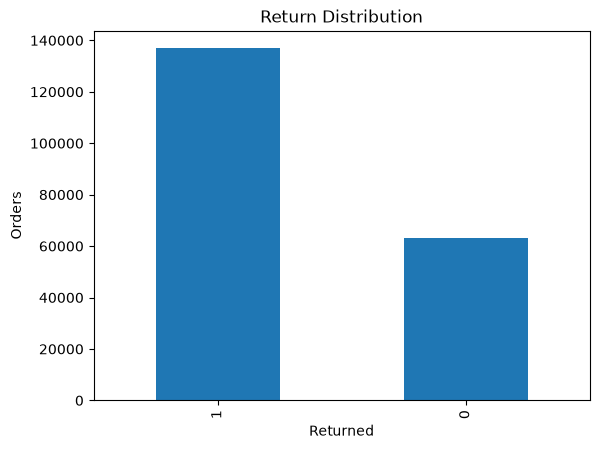

In [23]:
import matplotlib.pyplot as plt

df["returned"].value_counts().plot(kind="bar")

plt.title("Return Distribution")
plt.xlabel("Returned")
plt.ylabel("Orders")
plt.show()

In [24]:
TARGET = "returned"

DROP_COLUMNS = [
    "order_id",
    "returned",
    "rto",
    "return_reason",
    "return_cost",
    "inventory_loss",
    "restocking_cost",
    "return_shipping_cost",
]

In [25]:
df["order_timestamp"] = pd.to_datetime(df["order_timestamp"])

df = df.sort_values("order_timestamp").reset_index(drop=True)

print(df["order_timestamp"].min())
print(df["order_timestamp"].max())

2025-01-01 00:00:00
2026-08-31 23:58:00


In [26]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (140000, 33)
Validation: (30000, 33)
Test: (30000, 33)


In [27]:
print("TRAIN")
print(train_df["order_timestamp"].min(), "→", train_df["order_timestamp"].max())

print("\nVALIDATION")
print(val_df["order_timestamp"].min(), "→", val_df["order_timestamp"].max())

print("\nTEST")
print(test_df["order_timestamp"].min(), "→", test_df["order_timestamp"].max())

TRAIN
2025-01-01 00:00:00 → 2026-03-02 14:57:00

VALIDATION
2026-03-02 14:57:00 → 2026-06-01 19:53:00

TEST
2026-06-01 19:55:00 → 2026-08-31 23:58:00


In [28]:
FEATURE_DROP = [
    "order_id",
    "order_timestamp",
    "returned",
    "rto",
    "return_reason",
    "return_cost",
    "inventory_loss",
    "restocking_cost",
    "return_shipping_cost",
]

X_train = train_df.drop(columns=FEATURE_DROP)
y_train = train_df["returned"]

X_val = val_df.drop(columns=FEATURE_DROP)
y_val = val_df["returned"]

X_test = test_df.drop(columns=FEATURE_DROP)
y_test = test_df["returned"]

print(X_train.shape)
print(y_train.shape)

(140000, 24)
(140000,)


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identify feature types
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['merchant_id', 'customer_id', 'product_id', 'customer_age', 'account_age_days', 'past_purchase_count', 'past_return_rate', 'past_rto_rate', 'product_price', 'product_rating', 'discount_percent', 'new_device', 'is_first_order', 'used_coupon', 'session_length_minutes', 'num_product_views', 'estimated_delivery_days', 'delivery_distance_km', 'order_value', 'gross_margin']

Categorical features: ['product_category', 'payment_method', 'shipping_method', 'device_type']


C:\Users\skans\AppData\Local\Temp\ipykernel_18276\2227892336.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [30]:
FEATURE_DROP = [
    "order_id",
    "order_timestamp",
    "merchant_id",
    "customer_id",
    "product_id",
    "returned",
    "rto",
    "return_reason",
    "return_cost",
    "inventory_loss",
    "restocking_cost",
    "return_shipping_cost",
]

X_train = train_df.drop(columns=FEATURE_DROP)
y_train = train_df["returned"]

X_val = val_df.drop(columns=FEATURE_DROP)
y_val = val_df["returned"]

X_test = test_df.drop(columns=FEATURE_DROP)
y_test = test_df["returned"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (140000, 21)
y_train: (140000,)


In [31]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['customer_age', 'account_age_days', 'past_purchase_count', 'past_return_rate', 'past_rto_rate', 'product_price', 'product_rating', 'discount_percent', 'new_device', 'is_first_order', 'used_coupon', 'session_length_minutes', 'num_product_views', 'estimated_delivery_days', 'delivery_distance_km', 'order_value', 'gross_margin']

Categorical features: ['product_category', 'payment_method', 'shipping_method', 'device_type']


C:\Users\skans\AppData\Local\Temp\ipykernel_18276\1208623174.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Pipeline created successfully.")

Pipeline created successfully.


In [33]:
import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

start_time = time.time()

logistic_model.fit(X_train, y_train)

train_time = time.time() - start_time

# Validation predictions
y_val_pred = logistic_model.predict(X_val)
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]

print(f"Training time: {train_time:.2f} seconds")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1:        {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"PR-AUC:    {average_precision_score(y_val, y_val_prob):.4f}")
print(f"Brier:     {brier_score_loss(y_val, y_val_prob):.4f}")

Training time: 0.44 seconds
Accuracy:  0.6947
Precision: 0.7082
Recall:    0.9456
F1:        0.8099
ROC-AUC:   0.6599
PR-AUC:    0.8015
Brier:     0.2002


In [34]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

start_time = time.time()

xgb_model.fit(X_train, y_train)

train_time = time.time() - start_time

y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(f"Training time: {train_time:.2f} seconds")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_xgb):.4f}")
print(f"F1:        {f1_score(y_val, y_val_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_prob_xgb):.4f}")
print(f"PR-AUC:    {average_precision_score(y_val, y_val_prob_xgb):.4f}")
print(f"Brier:     {brier_score_loss(y_val, y_val_prob_xgb):.4f}")

Training time: 1.98 seconds
Accuracy:  0.6935
Precision: 0.7077
Recall:    0.9443
F1:        0.8091
ROC-AUC:   0.6564
PR-AUC:    0.7981
Brier:     0.2010


In [35]:
# Check numerical feature correlations with the target
correlations = (
    train_df[numeric_features + ["returned"]]
    .corr(numeric_only=True)["returned"]
    .drop("returned")
    .sort_values(key=abs, ascending=False)
)

print("Feature correlations with return:")
print(correlations)

Feature correlations with return:
past_return_rate           0.187745
past_rto_rate              0.061731
discount_percent           0.050835
num_product_views          0.045256
new_device                 0.043520
session_length_minutes     0.032770
product_rating            -0.026484
past_purchase_count        0.014594
used_coupon                0.009119
order_value               -0.008797
gross_margin              -0.007224
account_age_days          -0.004837
delivery_distance_km      -0.002522
estimated_delivery_days   -0.002162
product_price             -0.001845
is_first_order             0.000851
customer_age              -0.000194
Name: returned, dtype: float64


In [36]:
import joblib

joblib.dump(logistic_model, "../models/marginguard_logistic_v1.pkl")

print("Model saved successfully.")

Model saved successfully.


In [37]:
SIM_PATH = "../data/raw/marginguard_simulation_ground_truth_v2.csv"

sim_df = pd.read_csv(SIM_PATH)

sim_df["order_timestamp"] = pd.to_datetime(sim_df["order_timestamp"])

print("Simulation data:", sim_df.shape)
sim_df.head()

Simulation data: (200000, 43)


,order_id,merchant_id,customer_id,product_id,order_timestamp,customer_age,account_age_days,past_purchase_count,past_return_rate,past_rto_rate,...,verification_cost,manual_review_cost,cod_confirmation_cost,verification_effectiveness,cod_confirmation_effectiveness,manual_review_effectiveness,verification_abandonment,manual_review_abandonment,latent_return_probability,latent_rto_probability
0,ORD0170257,53,18855,4721,2025-01-01 00:00:00,24,1103,8,0.3211,0.2592,...,18.0,65.0,7.0,0.1714,0.1727,0.3239,0.0251,0.0469,0.46360,0.09629
1,ORD0033561,11,11806,1709,2025-01-01 00:02:00,25,110,13,0.6136,0.2370,...,18.0,65.0,7.0,0.2688,0.0969,0.3477,0.0105,0.0486,0.44290,0.14134
2,ORD0130882,27,26884,8121,2025-01-01 00:04:00,31,98,5,0.3879,0.1557,...,18.0,65.0,7.0,0.1957,0.3287,0.4041,0.0234,0.0466,0.56135,0.16378
3,ORD0190158,67,17432,8384,2025-01-01 00:06:00,24,188,6,0.1098,0.3350,...,18.0,65.0,7.0,0.2564,0.1225,0.4124,0.0210,0.0575,0.67575,0.17725
4,ORD0113335,8,27339,6317,2025-01-01 00:07:00,18,436,12,0.3273,0.0768,...,18.0,65.0,7.0,0.1388,0.1383,0.4731,0.0263,0.0529,0.63042,0.04690


In [38]:
val_prob = logistic_model.predict_proba(X_val)[:, 1]

policy_df = val_df.copy()
policy_df["predicted_return_probability"] = val_prob

print(policy_df[[
    "order_id",
    "predicted_return_probability",
    "returned",
    "return_cost"
]].head())

          order_id  predicted_return_probability  returned  return_cost
140000  ORD0131380                      0.679291         0         0.00
140001  ORD0153159                      0.709333         1       328.11
140002  ORD0192290                      0.779278         1       451.28
140003  ORD0186728                      0.813300         1       114.65
140004  ORD0071289                      0.456429         0         0.00


In [39]:
intervention_cols = [
    "order_id",
    "verification_cost",
    "manual_review_cost",
    "cod_confirmation_cost",
    "verification_effectiveness",
    "cod_confirmation_effectiveness",
    "manual_review_effectiveness",
    "verification_abandonment",
    "manual_review_abandonment"
]

policy_df = policy_df.merge(
    sim_df[intervention_cols],
    on="order_id",
    how="left"
)

print(policy_df.shape)

(30000, 42)


In [40]:
policy_df["expected_loss_no_action"] = (
    policy_df["predicted_return_probability"]
    * policy_df["return_cost"]
)

In [41]:
policy_df["expected_loss_verify"] = (
    policy_df["verification_cost"]
    +
    policy_df["predicted_return_probability"]
    * (1 - policy_df["verification_effectiveness"])
    * policy_df["return_cost"]
    +
    policy_df["verification_abandonment"]
    * policy_df["gross_margin"]
)

In [42]:
policy_df["expected_loss_cod_confirmation"] = (
    policy_df["cod_confirmation_cost"]
    +
    policy_df["predicted_return_probability"]
    * (1 - policy_df["cod_confirmation_effectiveness"])
    * policy_df["return_cost"]
)

In [43]:
policy_df["expected_loss_manual_review"] = (
    policy_df["manual_review_cost"]
    +
    policy_df["predicted_return_probability"]
    * (1 - policy_df["manual_review_effectiveness"])
    * policy_df["return_cost"]
    +
    policy_df["manual_review_abandonment"]
    * policy_df["gross_margin"]
)

In [44]:
loss_columns = {
    "NO_ACTION": "expected_loss_no_action",
    "VERIFY": "expected_loss_verify",
    "COD_CONFIRMATION": "expected_loss_cod_confirmation",
    "MANUAL_REVIEW": "expected_loss_manual_review"
}

policy_df["recommended_action"] = (
    policy_df[list(loss_columns.values())]
    .idxmin(axis=1)
    .map({v: k for k, v in loss_columns.items()})
)

policy_df["expected_loss"] = (
    policy_df[list(loss_columns.values())]
    .min(axis=1)
)

print(policy_df["recommended_action"].value_counts())

recommended_action
COD_CONFIRMATION    14304
NO_ACTION            9631
VERIFY               4521
MANUAL_REVIEW        1544
Name: count, dtype: int64


In [45]:
policy_df[[
    "order_id",
    "predicted_return_probability",
    "expected_loss_no_action",
    "expected_loss_verify",
    "expected_loss_cod_confirmation",
    "expected_loss_manual_review",
    "recommended_action"
]].head(20)

,order_id,predicted_return_probability,expected_loss_no_action,expected_loss_verify,expected_loss_cod_confirmation,expected_loss_manual_review,recommended_action
0,ORD0131380,0.679291,0.000000,25.400041,7.000000,79.648175,NO_ACTION
1,ORD0153159,0.709333,232.739309,198.394401,163.074980,195.138205,COD_CONFIRMATION
2,ORD0192290,0.779278,351.672401,307.618708,297.762741,293.958827,MANUAL_REVIEW
3,ORD0186728,0.813300,93.244878,87.701903,90.006590,128.370987,VERIFY
4,ORD0071289,0.456429,0.000000,21.500288,7.000000,74.347360,NO_ACTION
5,ORD0156491,0.698424,136.409126,138.795345,122.333916,178.950207,COD_CONFIRMATION
6,ORD0062180,0.626960,118.815269,122.504645,78.194109,147.094731,COD_CONFIRMATION
7,ORD0166849,0.718352,0.000000,21.809605,7.000000,76.695730,NO_ACTION
8,ORD0120678,0.604083,87.054462,102.312960,82.606800,135.076549,COD_CONFIRMATION
9,ORD0133710,0.714281,0.000000,24.520275,7.000000,78.880941,NO_ACTION


In [46]:
# Baseline: no intervention
baseline_loss = policy_df["expected_loss_no_action"].sum()

# MarginGuard policy
marginguard_loss = policy_df["expected_loss"].sum()

savings = baseline_loss - marginguard_loss
savings_percent = (savings / baseline_loss) * 100

print(f"Baseline expected loss: ₹{baseline_loss:,.2f}")
print(f"MarginGuard expected loss: ₹{marginguard_loss:,.2f}")
print(f"Expected savings: ₹{savings:,.2f}")
print(f"Savings percentage: {savings_percent:.2f}%")

Baseline expected loss: ₹4,638,345.71
MarginGuard expected loss: ₹3,599,207.26
Expected savings: ₹1,039,138.46
Savings percentage: 22.40%


In [47]:
# Final predictions on the untouched test set

y_test_pred = logistic_model.predict(X_test)
y_test_prob = logistic_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_test_prob):.4f}")
print(f"Brier:     {brier_score_loss(y_test, y_test_prob):.4f}")

Accuracy:  0.6917
Precision: 0.7048
Recall:    0.9461
F1:        0.8078
ROC-AUC:   0.6554
PR-AUC:    0.7974
Brier:     0.2019


In [48]:
test_policy_df = test_df.copy()

test_policy_df["predicted_return_probability"] = y_test_prob

test_policy_df = test_policy_df.merge(
    sim_df[intervention_cols],
    on="order_id",
    how="left"
)

print("Test policy dataset:", test_policy_df.shape)

Test policy dataset: (30000, 42)


In [49]:
test_policy_df["expected_loss_no_action"] = (
    test_policy_df["predicted_return_probability"]
    * test_policy_df["return_cost"]
)

test_policy_df["expected_loss_verify"] = (
    test_policy_df["verification_cost"]
    + test_policy_df["predicted_return_probability"]
    * (1 - test_policy_df["verification_effectiveness"])
    * test_policy_df["return_cost"]
    + test_policy_df["verification_abandonment"]
    * test_policy_df["gross_margin"]
)

test_policy_df["expected_loss_cod_confirmation"] = (
    test_policy_df["cod_confirmation_cost"]
    + test_policy_df["predicted_return_probability"]
    * (1 - test_policy_df["cod_confirmation_effectiveness"])
    * test_policy_df["return_cost"]
)

test_policy_df["expected_loss_manual_review"] = (
    test_policy_df["manual_review_cost"]
    + test_policy_df["predicted_return_probability"]
    * (1 - test_policy_df["manual_review_effectiveness"])
    * test_policy_df["return_cost"]
    + test_policy_df["manual_review_abandonment"]
    * test_policy_df["gross_margin"]
)

In [50]:
loss_columns = {
    "NO_ACTION": "expected_loss_no_action",
    "VERIFY": "expected_loss_verify",
    "COD_CONFIRMATION": "expected_loss_cod_confirmation",
    "MANUAL_REVIEW": "expected_loss_manual_review"
}

test_policy_df["recommended_action"] = (
    test_policy_df[list(loss_columns.values())]
    .idxmin(axis=1)
    .map({v: k for k, v in loss_columns.items()})
)

test_policy_df["expected_loss"] = (
    test_policy_df[list(loss_columns.values())]
    .min(axis=1)
)

print(test_policy_df["recommended_action"].value_counts())

recommended_action
COD_CONFIRMATION    14324
NO_ACTION            9718
VERIFY               4489
MANUAL_REVIEW        1469
Name: count, dtype: int64


In [51]:
baseline_test_loss = test_policy_df["expected_loss_no_action"].sum()
marginguard_test_loss = test_policy_df["expected_loss"].sum()

test_savings = baseline_test_loss - marginguard_test_loss
test_savings_percent = (test_savings / baseline_test_loss) * 100

print(f"Baseline loss:       ₹{baseline_test_loss:,.2f}")
print(f"MarginGuard loss:    ₹{marginguard_test_loss:,.2f}")
print(f"Expected savings:    ₹{test_savings:,.2f}")
print(f"Savings percentage:  {test_savings_percent:.2f}%")

Baseline loss:       ₹4,614,851.51
MarginGuard loss:    ₹3,579,779.39
Expected savings:    ₹1,035,072.12
Savings percentage:  22.43%


In [52]:
# Estimated return cost available BEFORE the order outcome

def estimate_return_cost(order_value):
    shipping = 70 + 0.0008 * order_value
    restocking = 25 + 0.015 * order_value
    expected_inventory_loss = 0.10 * order_value

    return shipping + restocking + expected_inventory_loss


test_policy_df["estimated_return_cost"] = (
    test_policy_df["order_value"]
    .apply(estimate_return_cost)
)

test_policy_df["estimated_gross_margin"] = (
    test_policy_df["order_value"] * 0.27
)

test_policy_df[
    ["order_value", "estimated_return_cost", "estimated_gross_margin"]
].head()

,order_value,estimated_return_cost,estimated_gross_margin
0,757.34,182.699972,204.4818
1,1186.90,232.443020,320.4630
2,2151.11,344.098538,580.7997
3,1190.31,232.837898,321.3837
4,385.32,139.620056,104.0364


In [53]:
test_policy_df["expected_loss_no_action"] = (
    test_policy_df["predicted_return_probability"]
    * test_policy_df["estimated_return_cost"]
)

test_policy_df["expected_loss_verify"] = (
    test_policy_df["verification_cost"]
    + test_policy_df["predicted_return_probability"]
    * (1 - test_policy_df["verification_effectiveness"])
    * test_policy_df["estimated_return_cost"]
    + test_policy_df["verification_abandonment"]
    * test_policy_df["estimated_gross_margin"]
)

test_policy_df["expected_loss_cod_confirmation"] = (
    test_policy_df["cod_confirmation_cost"]
    + test_policy_df["predicted_return_probability"]
    * (1 - test_policy_df["cod_confirmation_effectiveness"])
    * test_policy_df["estimated_return_cost"]
)

test_policy_df["expected_loss_manual_review"] = (
    test_policy_df["manual_review_cost"]
    + test_policy_df["predicted_return_probability"]
    * (1 - test_policy_df["manual_review_effectiveness"])
    * test_policy_df["estimated_return_cost"]
    + test_policy_df["manual_review_abandonment"]
    * test_policy_df["estimated_gross_margin"]
)

In [54]:
test_policy_df["recommended_action"] = (
    test_policy_df[list(loss_columns.values())]
    .idxmin(axis=1)
    .map({v: k for k, v in loss_columns.items()})
)

test_policy_df["expected_loss"] = (
    test_policy_df[list(loss_columns.values())]
    .min(axis=1)
)

In [55]:
baseline_test_loss = test_policy_df["expected_loss_no_action"].sum()
marginguard_test_loss = test_policy_df["expected_loss"].sum()

test_savings = baseline_test_loss - marginguard_test_loss
test_savings_percent = (test_savings / baseline_test_loss) * 100

print(f"Baseline estimated loss: ₹{baseline_test_loss:,.2f}")
print(f"MarginGuard estimated loss: ₹{marginguard_test_loss:,.2f}")
print(f"Estimated savings: ₹{test_savings:,.2f}")
print(f"Savings percentage: {test_savings_percent:.2f}%")

Baseline estimated loss: ₹6,505,790.46
MarginGuard estimated loss: ₹5,103,298.62
Estimated savings: ₹1,402,491.84
Savings percentage: 21.56%
